# Chapter 5 - Pipelines

**Name:** Mohammad Fauzi Hadiwijaya  
**Course:** Machine Learning  
**Source Book:** Introduction to Machine Learning with Python

## Objectives

- Understand machine learning pipelines
- Learn preprocessing workflow
- Use StandardScaler
- Combine preprocessing and model training

## What is a Pipeline?

A pipeline is a sequence of data processing steps followed by model training.

It helps automate workflow and ensures all preprocessing steps are consistently applied.

## Why Use Pipelines?

### Benefits:

- Cleaner code
- Easier model management
- Prevent data leakage
- Faster experimentation

In [1]:
# Import libraries
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [2]:
# Load dataset
cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data,
    cancer.target,
    random_state=42
)

## Build Pipeline

We combine:

1. StandardScaler  
2. KNN Classifier

In [3]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=3))
])

pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(n_neighbors=3))])

In [4]:
train_score = pipe.score(X_train, y_train)
test_score = pipe.score(X_test, y_test)

print("Training Accuracy :", train_score)
print("Testing Accuracy  :", test_score)

Training Accuracy : 0.9835680751173709
Testing Accuracy  : 0.958041958041958


## Visual Comparison

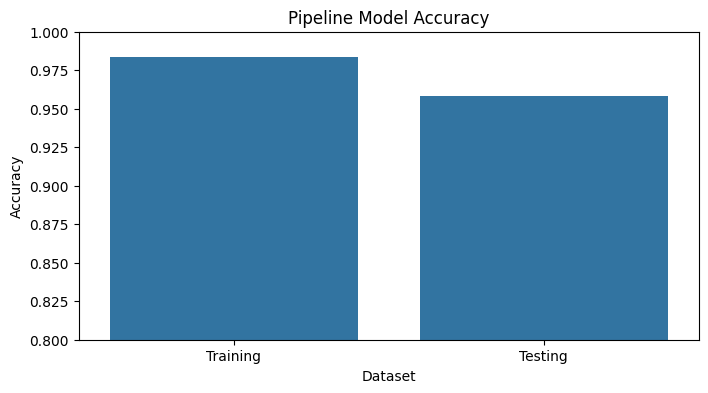

In [5]:
scores = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Accuracy": [train_score, test_score]
})

plt.figure(figsize=(8,4))
sns.barplot(data=scores, x="Dataset", y="Accuracy")

plt.ylim(0.8,1.0)
plt.title("Pipeline Model Accuracy")
plt.show()

## Interpretation

The pipeline improves workflow efficiency by combining preprocessing and model training in one structure.

Scaling is important for KNN because distance-based models are sensitive to feature scale.

## Conclusion

- Pipelines simplify machine learning workflow.
- StandardScaler improves feature consistency.
- KNN performs better when data is scaled.